# Severity Score Classification

AI/ML Engineer Technical Assessment. Full write-up in `README.md`; this
notebook runs the same pipeline (from `src/`) end to end with inline
results, so nothing here duplicates logic that already lives in a tested
module.


In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
pd.set_option('display.max_columns', 50)


## Phase 1 — Data audit and leakage investigation

Full detail in `docs/phase1_audit.md` (regenerate with `python src/audit.py`).
Headline finding: `SeverityScore` distribution is imbalanced (class 6 = 101/2000
rows), and five columns turned out to be near-deterministic functions of the
target -- computed *after* severity is assessed -- so they're excluded from
modelling entirely.

In [2]:
from features import load_dataset, engineer_features, TARGET

train_df = load_dataset('../data/training_dataset.csv')
holdback_df = load_dataset('../data/holdback_dataset.csv')
print('train:', train_df.shape, 'holdback:', holdback_df.shape)
train_df[TARGET].value_counts().sort_index()


train: (2000, 46) holdback: (500, 45)


SeverityScore
1    504
2    491
3    404
4    297
5    203
6    101
Name: count, dtype: int64

In [3]:
suspects = ['EstimatedImpactScore', 'EstimatedRiskScore', 'ExpectedFinancialRedressGBP']
train_df[suspects + [TARGET]].corr()[TARGET]


EstimatedImpactScore           0.940960
EstimatedRiskScore             0.797337
ExpectedFinancialRedressGBP    0.561834
SeverityScore                  1.000000
Name: SeverityScore, dtype: float64

In [4]:
train_df.groupby('PredictedRemedyBand')[TARGET].mean().sort_values()

PredictedRemedyBand
A    1.204473
B    1.901408
C    3.252492
D    4.639175
E    5.584416
F    6.000000
Name: SeverityScore, dtype: float64

In [5]:
train_df.groupby('OmbudsmanInvestigationRequired')[TARGET].mean()

OmbudsmanInvestigationRequired
No     1.928520
Yes    4.673877
Name: SeverityScore, dtype: float64

**Verdict:** `EstimatedImpactScore` (r=0.94), `EstimatedRiskScore` (r=0.80),
`PredictedRemedyBand` (monotonic 1.2 -> 6.0), `OmbudsmanInvestigationRequired`
(1.93 vs 4.67), and `ExpectedFinancialRedressGBP` (r=0.56, borderline) are all
excluded as leakage. `CaseReference` is an id, `CaseCreatedDate` has no signal
(month vs severity correlation = -0.004, see `docs/phase1_audit.md`).

## Feature engineering and preprocessing pipeline

Shared infrastructure (`src/features.py`), used by every phase below rather
than being its own numbered phase. It is the single source of truth for the locked feature set,
the three engineered features, and the reproducible `sklearn` `ColumnTransformer`
(median/most-frequent imputation, ordinal encoding for genuinely ordered
scales, one-hot for nominal categories). "None" is preserved as a real
category, not treated as missing, for the columns where the data dictionary
defines it as one.

In [6]:
from features import build_preprocessor, get_feature_columns

df = engineer_features(train_df)
X = df[get_feature_columns()]
y = df[TARGET]

pre = build_preprocessor()
Xt = pre.fit_transform(X)
print('features in:', X.shape[1], '-> after encoding:', Xt.shape[1])


features in: 41 -> after encoding: 87


## Phase 2 — Baseline and candidate model comparison

A majority-class dummy baseline, Logistic Regression, Random Forest,
LightGBM, and CatBoost compared under identical stratified 5-fold CV
(seed 42). Full table and confusion matrices in
`docs/phase2_model_comparison.md` (regenerate with
`python src/model_comparison.py` -- takes a few minutes, not rerun here).


In [7]:
import pandas as pd
comparison_path = '../docs/phase2_model_comparison.md'
print(open(comparison_path).read()[:1400])


# Phase 2 Model Comparison

5-fold stratified CV, same folds across all models. Class weights balanced throughout given the target imbalance (class 6 has only 101/2000 examples).

Headline business metric: **severe_recall** (recall on SeverityScore>=4), given the brief's stated low tolerance for missing severe cases.

| model                 |   macro_f1_mean |   balanced_accuracy_mean |   severe_recall_mean |   severe_precision_mean |   severe_f1_mean |
|:----------------------|----------------:|-------------------------:|---------------------:|------------------------:|-----------------:|
| MajorityClassBaseline |           0.067 |                    0.167 |                0     |                   0     |            0     |
| LogisticRegression    |           0.41  |                    0.429 |                0.767 |                   0.675 |            0.718 |
| RandomForest          |           0.442 |                    0.43  |                0.624 |                   0.778 |     

**Headline metric is `severe_recall`** (recall on SeverityScore >= 4), not
raw accuracy, per the brief's explicit low tolerance for missing severe
cases. All categorical features are ordinal/one-hot encoded by the shared
`ColumnTransformer` before reaching any model -- CatBoost is not using its
native categorical-feature handling here. It simply performs best on the
encoded categorical-heavy feature set (best severe-case F1 and macro F1),
so it was selected as the candidate to tune further.

## Phase 3 — Hyperparameter tuning and the recall/workload trade-off

Grid search over CatBoost depth/iterations/learning_rate, scored on
severe-case F1 under the same CV scheme. Full table in
`docs/phase3_tuning_and_threshold.md` (regenerate with
`python src/tune_and_threshold.py`).

In [8]:
print(open('../docs/phase3_tuning_and_threshold.md').read())

# Phase 3: Hyperparameter Tuning and Threshold Trade-off

## CatBoost hyperparameter search (5-fold CV, scored on severe-case F1)

|   depth |   iterations |   learning_rate |   severe_f1 |
|--------:|-------------:|----------------:|------------:|
|       6 |          600 |            0.03 |       0.748 |
|       6 |          300 |            0.03 |       0.747 |
|       4 |          300 |            0.03 |       0.746 |
|       4 |          600 |            0.03 |       0.746 |
|       8 |          300 |            0.03 |       0.744 |
|       6 |          300 |            0.1  |       0.739 |
|       8 |          600 |            0.03 |       0.738 |
|       4 |          600 |            0.1  |       0.734 |
|       4 |          300 |            0.1  |       0.733 |
|       6 |          600 |            0.1  |       0.73  |
|       8 |          300 |            0.1  |       0.717 |
|       8 |          600 |            0.1  |       0.713 |

Best params: `{'depth': 6, 'iterations': 6

**Proposed operating threshold: 0.30** on P(SeverityScore >= 4), instead of
the default 0.5 argmax cut-off. This raises severe-case recall from 0.759
to 0.900 at the cost of ~268 additional cases sent for investigation
review (on the 2,000 training rows). The brief gives no numeric recall
target, so 0.30 is a proposed operating point for business sign-off, not
a mathematically optimal answer -- it should move based on actual
investigative capacity. Note also the methodological caveat: this
threshold is chosen using the same out-of-fold predictions used to select
CatBoost's hyperparameters, so it's an internal training-set analysis,
not an independent, unbiased estimate (see `docs/phase3_tuning_and_threshold.md`
for the full discussion).

## Phase 4 — Explainability and error analysis

SHAP values (global + the false-negative breakdown) in
`docs/phase4_explainability_error_analysis.md` and `outputs/shap_summary.png`
(regenerate with `python src/explainability.py`).

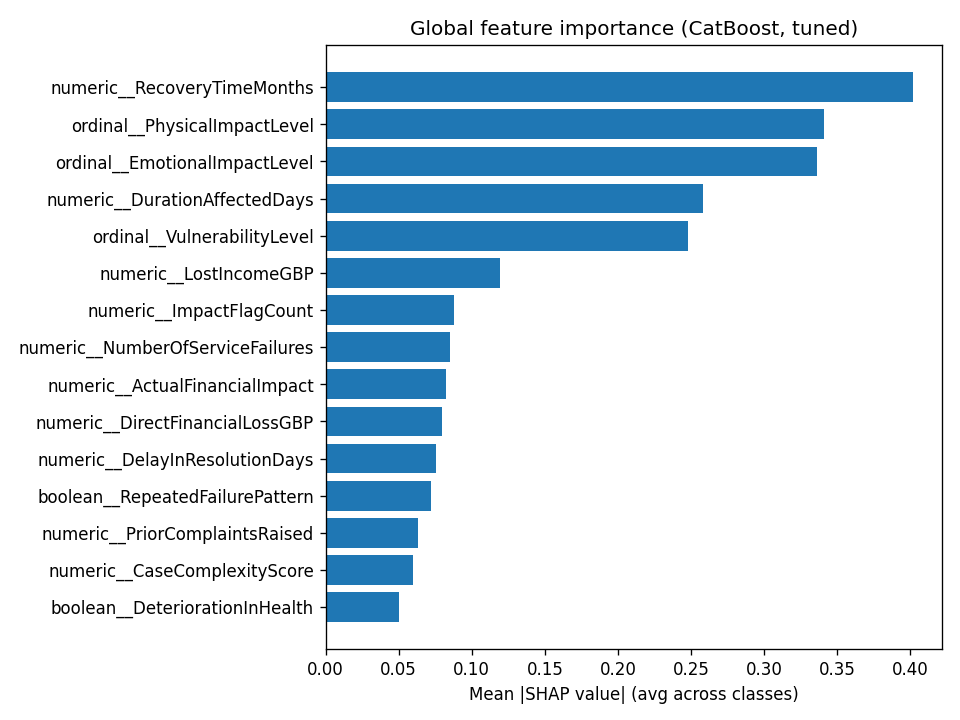

In [9]:
from IPython.display import Image
Image('../outputs/shap_summary.png')

In [10]:
print(open('../docs/phase4_explainability_error_analysis.md').read())

# Phase 4: Explainability and Error Analysis

## Global feature importance (mean |SHAP|, averaged across classes)

|                                        |   mean_abs_shap |
|:---------------------------------------|----------------:|
| numeric__RecoveryTimeMonths            |          0.4016 |
| ordinal__PhysicalImpactLevel           |          0.3412 |
| ordinal__EmotionalImpactLevel          |          0.3363 |
| numeric__DurationAffectedDays          |          0.2579 |
| ordinal__VulnerabilityLevel            |          0.2479 |
| numeric__LostIncomeGBP                 |          0.1191 |
| numeric__ImpactFlagCount               |          0.0882 |
| numeric__NumberOfServiceFailures       |          0.0851 |
| numeric__ActualFinancialImpact         |          0.0822 |
| numeric__DirectFinancialLossGBP        |          0.0799 |
| numeric__DelayInResolutionDays         |          0.0757 |
| boolean__RepeatedFailurePattern        |          0.072  |
| numeric__PriorComplaintsRaise

SHAP shows that the model's strongest predictors (`RecoveryTimeMonths`,
`PhysicalImpactLevel`, `EmotionalImpactLevel`, `DurationAffectedDays`,
`VulnerabilityLevel`) line up with the severity factors named in the
brief -- a useful sanity check on model behaviour, though SHAP shows
influence on the model's predictions, not causal validity against
real-world severity.

False negatives (severe cases missed under the default argmax decision)
skew toward shorter duration and lower financial impact than correctly
caught severe cases -- i.e. borderline cases that look moderate on the
surface. Exploratory analysis of category shares did not reveal an
obvious large disparity across the vulnerability groups examined (this is
not a formal fairness assessment -- no per-group recall, confidence
intervals, or minimum sample-size checks were computed), though
Homelessness and Immigration cases were somewhat over-represented among
misses and are worth monitoring in production. A calibration check
(Brier score 0.107 vs a 0.210 prevalence baseline) suggests useful
probability ranking behaviour, but the scores are not independently
calibrated and should be read as a risk score, not a precise
probability.

## Phase 5 — Final model and holdback predictions

Retrain on all 2,000 training rows with the tuned hyperparameters
(`src/train.py`), then score the 500-row holdback set (`src/predict.py`).


In [11]:
!python ../src/train.py

Trained on 2000 rows. Saved models/final_pipeline.joblib


In [12]:
!python ../src/predict.py

Scored 500 holdback cases -> D:\Assignment\severity-model\outputs\holdback_predictions.csv (REQUIRED submission file)
Supporting analysis -> D:\Assignment\severity-model\outputs\holdback_operational_analysis.csv (not required, for transparency)
PredictedSeverityScore
1    140
2    103
3     77
4     88
5     63
6     29
Name: count, dtype: int64
RecommendedAction
Not progressed                270
Progress for investigation    230
Name: count, dtype: int64


In [13]:
preds = pd.read_csv('../outputs/holdback_predictions.csv')
preds.head(10)

,CaseReference,PredictedSeverityScore
0,HLD-000001,6
1,HLD-000002,5
2,HLD-000003,1
3,HLD-000004,2
4,HLD-000005,4
5,HLD-000006,3
6,HLD-000007,2
7,HLD-000008,3
8,HLD-000009,2
9,HLD-000010,4


In [14]:
preds['PredictedSeverityScore'].value_counts().sort_index()

PredictedSeverityScore
1    140
2    103
3     77
4     88
5     63
6     29
Name: count, dtype: int64

## Summary

- Leakage audit removed 5 columns that would have made the model look
  deceptively strong while solving the wrong problem.
- CatBoost, tuned, selected on severe-case F1 (business-risk-aligned
  metric), not raw accuracy.
- Decision threshold lowered from the default 0.5 to 0.30 to trade
  investigation workload for severe-case recall, per the brief's stated
  risk tolerance.
- SHAP shows the model's strongest predictors align with the severity
  factors named in the brief; exploratory error analysis did not reveal
  an obvious large disparity by vulnerability group among missed severe
  cases, though this was not a formal fairness assessment.
- Final predictions: `outputs/holdback_predictions.csv`.

See `README.md` for the full write-up, repository structure, and
reproduction steps.